In [83]:
import pyodbc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

sql data import

In [84]:
sql_conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=Excel;"
    "UID=AS;"
    "PWD=Sur7aj6@;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

print("✅ SQL Server Connected Successfully!")

✅ SQL Server Connected Successfully!


In [85]:
df = pd.read_sql("SELECT * FROM Sales_Data", sql_conn)

C:\Users\Anish Kumar\AppData\Local\Temp\ipykernel_3936\470251366.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM Sales_Data", sql_conn)


In [86]:
df.head(5)

,OrderID,OrderDate,Customer,City,Product,Category,Quantity,UnitPrice,Sales,Salesperson,Region,PaymentMode
0,ORD10001,2025-04-19,Customer_001,Delhi,Printer,Office,7,8500.0,59500.0,Anjali,North,Cash
1,ORD10002,2025-03-16,Customer_002,Bangalore,Keyboard,Accessories,4,1800.0,7200.0,Vikas,South,Credit Card
2,ORD10003,2025-05-26,Customer_003,Delhi,Chair,Furniture,7,7000.0,49000.0,Neha,North,Debit Card
3,ORD10004,2025-05-08,Customer_004,Delhi,Mouse,Accessories,6,900.0,5400.0,Priya,North,Net Banking
4,ORD10005,2025-02-11,Customer_005,Bangalore,Printer,Office,2,8500.0,17000.0,Vikas,South,Cash


In [87]:
df.tail(5)

,OrderID,OrderDate,Customer,City,Product,Category,Quantity,UnitPrice,Sales,Salesperson,Region,PaymentMode
495,ORD10496,2025-12-01,Customer_496,Noida,Laptop,Electronics,6,55000.0,330000.0,Neha,North,Debit Card
496,ORD10497,2026-02-22,Customer_497,Gurgaon,Printer,Office,4,8500.0,34000.0,Priya,North,Cash
497,ORD10498,2025-10-22,Customer_498,Delhi,Printer,Office,2,8500.0,17000.0,Pooja,North,Cash
498,ORD10499,2026-01-06,Customer_499,Pune,Desk,Furniture,2,11000.0,22000.0,Vikas,West,Credit Card
499,ORD10500,2025-07-05,Customer_500,Noida,Headphones,Accessories,5,2500.0,12500.0,Pooja,North,UPI


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      500 non-null    str    
 1   OrderDate    500 non-null    object 
 2   Customer     500 non-null    str    
 3   City         500 non-null    str    
 4   Product      500 non-null    str    
 5   Category     500 non-null    str    
 6   Quantity     500 non-null    int64  
 7   UnitPrice    500 non-null    float64
 8   Sales        500 non-null    float64
 9   Salesperson  500 non-null    str    
 10  Region       500 non-null    str    
 11  PaymentMode  500 non-null    str    
dtypes: float64(2), int64(1), object(1), str(8)
memory usage: 47.0+ KB


In [89]:
df.describe()

,Quantity,UnitPrice,Sales
count,500.000000,500.000000,500.000000
mean,4.098000,14667.000000,57241.000000
std,2.031909,16466.019269,75252.935542
min,1.000000,900.000000,900.000000
25%,2.000000,2500.000000,9000.000000
50%,4.000000,8500.000000,35000.000000
75%,6.000000,18000.000000,66000.000000
max,7.000000,55000.000000,385000.000000


In [90]:
df.dtypes

OrderID            str
OrderDate       object
Customer           str
City               str
Product            str
Category           str
Quantity         int64
UnitPrice      float64
Sales          float64
Salesperson        str
Region             str
PaymentMode        str
dtype: object

In [91]:
df.columns

Index(['OrderID', 'OrderDate', 'Customer', 'City', 'Product', 'Category',
       'Quantity', 'UnitPrice', 'Sales', 'Salesperson', 'Region',
       'PaymentMode'],
      dtype='str')

In [92]:
np.random.seed(42)
first_names = [
    "Aarav", "Aditi", "Aditya", "Akash", "Aman", "Amit", "Ananya", "Anjali", "Ankit", "Arjun",
    "Ashish", "Ayush", "Deepak", "Divya", "Gaurav", "Isha", "Karan", "Kavita", "Kunal", "Manish",
    "Meera", "Mohit", "Neha", "Nikhil", "Nisha", "Pankaj", "Pooja", "Prakash", "Priya", "Rahul",
    "Raj", "Rajat", "Rakesh", "Ravi", "Riya", "Rohit", "Sachin", "Sakshi", "Sameer", "Sandeep",
    "Sanjay", "Shivam", "Shreya", "Simran", "Sonali", "Sourav", "Sunil", "Swati", "Tarun", "Vikas",
    "Vikram", "Vineet", "Vishal", "Yash", "Yogesh", "Varun", "Komal", "Muskan", "Naveen", "Nitin",
    "Pawan", "Pranav", "Raghav", "Rajat", "Ramesh", "Rani", "Rashmi", "Reena", "Renu", "Richa",
    "Ritu", "Riya", "Rupali", "Sahil", "Sakshi", "Salman", "Samir", "Sana", "Sanjana", "Sarika",
    "Seema", "Shalini", "Shankar", "Shikha", "Shruti", "Siddharth", "Sneha", "Sonia", "Srishti", "Sumit",
    "Suraj", "Suresh", "Tanisha", "Tanya", "Tanu", "Tushar", "Uday", "Uma", "Vaibhav", "Varsha",
    "Vedant", "Veer", "Vijay", "Vinay", "Vivek", "Waseem", "Zaid", "Zoya", "Abhay", "Abhishek",
    "Adarsh", "Ajay", "Ajit", "Alok", "Amar", "Amisha", "Amol", "Anand", "Anil", "Anirudh",
    "Anisha", "Ansh", "Anshu", "Antara", "Apoorva", "Archana", "Arnav", "Arpita", "Aryan", "Ashok",
    "Avinash", "Bharat", "Bhavna", "Bhavesh", "Bhumika", "Chetan", "Chirag", "Darshan", "Daya", "Dev",
    "Devansh", "Dhanush", "Diksha", "Dinesh", "Ekta", "Farhan", "Faisal", "Garima", "Geeta", "Harish",
    "Harsh", "Harsha", "Himanshu", "Hina", "Inder", "Ishaan", "Jagdish", "Jatin", "Jaya", "Jayant",
    "Jeevan", "Jyoti", "Kabir", "Kajal", "Kamal", "Kanika", "Kartik", "Kashish", "Kavya", "Khushi",
    "Kirti", "Krishna", "Kriti", "Kunal", "Lakshay", "Lalit", "Lavanya", "Lokesh", "Madhav", "Madhu",
    "Mahesh", "Mahi", "Malini", "Mamta", "Mansi", "Mayank", "Meena", "Mihir", "Milan", "Mira",
    "Mohan", "Monika", "Mukesh", "Naina", "Naksh", "Namita", "Nandini", "Naresh", "Navin", "Nayan",
    "Neel", "Neelam", "Neeraj", "Nidhi", "Nikita", "Nilesh", "Nirmal", "Nitin", "Nivedita", "Ojas",
    "Om", "Palak", "Parag", "Pari", "Parth", "Payal", "Piyush", "Preeti", "Pritam", "Purva",
    "Rachit", "Radha", "Ragini", "Rajeev", "Rajesh", "Rajiv", "Ranjit", "Rashid", "Ravi", "Rekha",
    "Ritesh", "Rohini", "Roshan", "Ruchi", "Sachin", "Sagar", "Saloni", "Sameera", "Sanjay", "Santosh",
    "Saroj", "Saurabh", "Shahid", "Shailesh", "Shanaya", "Shashank", "Shekhar", "Shivani", "Shubham", "Shweta",
    "Siddhi", "Smita", "Sonal", "Sonam", "Sourabh", "Sparsh", "Suman", "Sunita", "Surabhi", "Sushant",
    "Sushil", "Swara", "Tanuja", "Tejas", "Tina", "Trisha", "Ujjwal", "Umesh", "Upasana", "Utkarsh",
    "Vandana", "Varun", "Vasu", "Vatsal", "Vidhi", "Vidya", "Vikas", "Vimal", "Vineeta", "Vipul",
    "Vishakha", "Vishnu", "Yamini", "Yatin", "Yuvraj", "Zara", "Ayesha", "Bilal", "Danish", "Imran",
    "Irfan", "Javed", "Kashif", "Nadeem", "Nazia", "Rizwan", "Saif", "Shabnam", "Shadab", "Shahnawaz",
    "Shoaib", "Sohail", "Tabassum", "Wasim", "Aaliya", "Aamir", "Afreen", "Alisha", "Armaan", "Asif",
    "Azhar", "Faizan", "Hammad", "Haseeb", "Humaira", "Kiran", "Lubna", "Mariam", "Mehreen", "Nusrat",
    "Rafia", "Rehan", "Rubina", "Saba", "Sabina", "Sadia", "Sahil", "Samina", "Shakir", "Shazia",
    "Aakash", "Aarohi", "Aastha", "Aayush", "Aditi", "Aishwarya", "Akansha", "Akshat", "Akshara", "Amrita",
    "Apoorv", "Aradhya", "Bharti", "Charu", "Damini", "Esha", "Gauri", "Ishita", "Jhanvi", "Juhi",
    "Kanchan", "Karishma", "Kriti", "Madhuri", "Mahima", "Manisha", "Manya", "Mitali", "Nandita", "Navya",
    "Niharika", "Pallavi", "Poonam", "Pragya", "Preeti", "Radhika", "Rajni", "Rashika", "Raveena", "Riddhi",
    "Roshni", "Sakina", "Salma", "Sapna", "Shanvi", "Shivangi", "Shreya", "Sonali", "Tanvi", "Tara",
    "Tulika", "Vaishali", "Vani", "Vasudha", "Veda", "Vidushi", "Yashika", "Zeenat", "Aarti", "Aarav",
    "Abhinav", "Advik", "Ahan", "Akhil", "Anmol", "Arpit", "Atharv", "Dhruv", "Harshit", "Hrithik",
    "Keshav", "Krish", "Laksh", "Manav", "Mudit", "Naman", "Nakul", "Parveen", "Prateek", "Raghav",
    "Ranveer", "Rituraj", "Shivam", "Shrey", "Tanish", "Tanu", "Utsav", "Vansh", "Varad", "Vivaan",
    "Yuvika", "Zubin", "Aarush", "Abeer", "Adit", "Aditiya", "Anshul", "Avni", "Bhavya", "Dhara",
    "Harshita", "Ishika", "Janvi", "Kashvi", "Kiana", "Myra", "Navneet", "Nitya", "Pari", "Prisha",
    "Rhea", "Saanvi", "Samaira", "Shanaya", "Siya", "Tia", "Vanya", "Zoya", "Ayesha", "Diya",
    "Ishani", "Mahi", "Mishka", "Ruhani", "Suhani", "Anvi", "Aarna", "Kiara", "Aadhya", "Aaradhya",
    "Aahana", "Anvika", "Charvi", "Devika", "Ira", "Jiya", "Kaira", "Navya", "Nyla", "Pranavi",
    "Riddhima", "Samaira", "Sharanya", "Shivanya", "Suhana", "Tanishka", "Vamika", "Vritika", "Yashvi", "Ziva"
]

last_names = [
    "Sharma", "Verma", "Kumar", "Singh", "Gupta",
    "Yadav", "Mishra", "Pandey", "Tiwari", "Jha",
    "Chauhan", "Rajput", "Thakur", "Sinha", "Prasad",
    "Agarwal", "Bansal", "Jain", "Sahu", "Saxena",
    "Srivastava", "Tripathi", "Dubey", "Dwivedi", "Shukla",
    "Pathak", "Joshi", "Mehta", "Shah", "Patel",
    "Desai", "Rao", "Reddy", "Naidu", "Iyer",
    "Nair", "Menon", "Pillai", "Kapoor", "Malhotra",
    "Arora", "Khanna", "Chopra", "Bhatia", "Sethi",
    "Ahuja", "Chawla", "Goyal", "Mittal", "Goel",
    "Kohli", "Bhardwaj", "Bhatt", "Rawat", "Negi",
    "Bisht", "Rana", "Dixit", "Prajapati", "Maurya",
    "Kushwaha", "Mandal", "Das", "Dutta", "Ghosh",
    "Bose", "Banerjee", "Mukherjee", "Chatterjee", "Sen",
    "Roy", "Pal", "Sarkar", "Nath", "Dey",
    "Soni", "Gupta", "Khatri", "Wadhwa", "Tandon",
    "Bajaj", "Singhal", "Aggarwal", "Puri", "Batra",
    "Khurana", "Anand", "Vohra", "Sachdeva", "Luthra",
    "Madan", "Bedi", "Talwar", "Oberoi", "Handa",
    "Mathur", "Kulkarni", "Deshmukh", "Patil", "More"
]
df["Customer"] = (
    np.random.choice(first_names, size=len(df)) + " " + np.random.choice(last_names, size=len(df))
)


In [93]:
df["PaymentMode"].unique()

<StringArray>
['Cash', 'Credit Card', 'Debit Card', 'Net Banking', 'UPI']
Length: 5, dtype: str

In [94]:
df["Region"].unique()

<StringArray>
['North', 'South', 'West', 'East']
Length: 4, dtype: str

In [95]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"],format="mixed").dt.strftime("%d/%m/%Y")

In [96]:
df.head(5)

,OrderID,OrderDate,Customer,City,Product,Category,Quantity,UnitPrice,Sales,Salesperson,Region,PaymentMode
0,ORD10001,19/04/2025,Vijay Patil,Delhi,Printer,Office,7,8500.0,59500.0,Anjali,North,Cash
1,ORD10002,16/03/2025,Myra Goel,Bangalore,Keyboard,Accessories,4,1800.0,7200.0,Vikas,South,Credit Card
2,ORD10003,26/05/2025,Jhanvi Shukla,Delhi,Chair,Furniture,7,7000.0,49000.0,Neha,North,Debit Card
3,ORD10004,08/05/2025,Vandana Dwivedi,Delhi,Mouse,Accessories,6,900.0,5400.0,Priya,North,Net Banking
4,ORD10005,11/02/2025,Zaid Thakur,Bangalore,Printer,Office,2,8500.0,17000.0,Vikas,South,Cash


North ka multiple columns data

In [97]:
North = df[df["Region"] == "North"][[
    "OrderID",
    "OrderDate",
    "Customer",
    "City",
    "Product",
    "Category",
    "Quantity",
    "UnitPrice",
    "Sales",
    "Salesperson",
    "Region",
    "PaymentMode" 
]]
North

,OrderID,OrderDate,Customer,City,Product,Category,Quantity,UnitPrice,Sales,Salesperson,Region,PaymentMode
0,ORD10001,19/04/2025,Vijay Patil,Delhi,Printer,Office,7,8500.0,59500.0,Anjali,North,Cash
2,ORD10003,26/05/2025,Jhanvi Shukla,Delhi,Chair,Furniture,7,7000.0,49000.0,Neha,North,Debit Card
3,ORD10004,08/05/2025,Vandana Dwivedi,Delhi,Mouse,Accessories,6,900.0,5400.0,Priya,North,Net Banking
7,ORD10008,03/02/2025,Meera Rana,Delhi,Printer,Office,4,8500.0,34000.0,Vikas,North,Debit Card
10,ORD10011,13/01/2026,Kaira Saxena,Gurgaon,Keyboard,Accessories,1,1800.0,1800.0,Priya,North,Credit Card
...,...,...,...,...,...,...,...,...,...,...,...,...
493,ORD10494,27/05/2026,Shashank Pandey,Delhi,Printer,Office,6,8500.0,51000.0,Neha,North,Debit Card
495,ORD10496,01/12/2025,Sameer Singh,Noida,Laptop,Electronics,6,55000.0,330000.0,Neha,North,Debit Card
496,ORD10497,22/02/2026,Vamika Bisht,Gurgaon,Printer,Office,4,8500.0,34000.0,Priya,North,Cash
497,ORD10498,22/10/2025,Khushi Shukla,Delhi,Printer,Office,2,8500.0,17000.0,Pooja,North,Cash


In [98]:
df[df["Region"] == "North"][["Customer","Product", "Quantity", "UnitPrice", "Sales"]]

,Customer,Product,Quantity,UnitPrice,Sales
0,Vijay Patil,Printer,7,8500.0,59500.0
2,Jhanvi Shukla,Chair,7,7000.0,49000.0
3,Vandana Dwivedi,Mouse,6,900.0,5400.0
7,Meera Rana,Printer,4,8500.0,34000.0
10,Kaira Saxena,Keyboard,1,1800.0,1800.0
...,...,...,...,...,...
493,Shashank Pandey,Printer,6,8500.0,51000.0
495,Sameer Singh,Laptop,6,55000.0,330000.0
496,Vamika Bisht,Printer,4,8500.0,34000.0
497,Khushi Shukla,Printer,2,8500.0,17000.0


## Pandas Question 

Q1. Calculate the total Sales.

In [99]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 28620500.0


Q2. Calculate the average Sales.

In [100]:
avg_sales = df["Sales"].mean().round(2)

print("Avg Sales:", avg_sales)

Avg Sales: 57241.0


Q3. Find the order with the maximum Sales.

In [101]:
max_Sales = df["Sales"].max()
print("Max Sales", max_Sales)

Max Sales 385000.0


Q4. Find the order with the minimum Sales.

In [102]:
min_Sales = df["Sales"].min()
print("Minimum Sales", min_Sales)

Minimum Sales 900.0


Q5. Find the top 10 orders with the highest Sales.

In [103]:
Highest_Sales = df.nlargest(10, "Sales")
Highest_Sales

,OrderID,OrderDate,Customer,City,Product,Category,Quantity,UnitPrice,Sales,Salesperson,Region,PaymentMode
51,ORD10052,03/06/2025,Yogesh Patil,Noida,Laptop,Electronics,7,55000.0,385000.0,Amit,North,Cash
78,ORD10079,14/11/2025,Riya Sharma,Pune,Laptop,Electronics,7,55000.0,385000.0,Amit,West,Net Banking
110,ORD10111,05/05/2026,Nitin Oberoi,Gurgaon,Laptop,Electronics,7,55000.0,385000.0,Neha,North,Debit Card
183,ORD10184,06/11/2025,Raghav Singhal,Pune,Laptop,Electronics,7,55000.0,385000.0,Rahul,West,Credit Card
268,ORD10269,02/03/2026,Ajit Sethi,Pune,Laptop,Electronics,7,55000.0,385000.0,Priya,West,UPI
294,ORD10295,21/08/2025,Nadeem Gupta,Noida,Laptop,Electronics,7,55000.0,385000.0,Neha,North,Debit Card
435,ORD10436,20/02/2026,Faisal Gupta,Mumbai,Laptop,Electronics,7,55000.0,385000.0,Priya,West,Net Banking
490,ORD10491,24/02/2026,Utsav Handa,Delhi,Laptop,Electronics,7,55000.0,385000.0,Amit,North,Debit Card
114,ORD10115,01/06/2025,Vishal More,Mumbai,Laptop,Electronics,6,55000.0,330000.0,Rohit,West,Debit Card
156,ORD10157,03/01/2025,Vaibhav Iyer,Mumbai,Laptop,Electronics,6,55000.0,330000.0,Rahul,West,Net Banking


Q6. Find the bottom 10 orders with the lowest Sales.

In [104]:
lower_Sales = df.nsmallest(10, "Sales")
lower_Sales

,OrderID,OrderDate,Customer,City,Product,Category,Quantity,UnitPrice,Sales,Salesperson,Region,PaymentMode
186,ORD10187,01/01/2026,Saroj Dubey,Mumbai,Mouse,Accessories,1,900.0,900.0,Pooja,West,Credit Card
386,ORD10387,21/01/2026,Radhika Prajapati,Patna,Mouse,Accessories,1,900.0,900.0,Anjali,East,Debit Card
418,ORD10419,13/08/2025,Rekha Singh,Pune,Mouse,Accessories,1,900.0,900.0,Amit,West,UPI
9,ORD10010,02/06/2025,Ansh Sethi,Pune,Mouse,Accessories,2,900.0,1800.0,Amit,West,UPI
10,ORD10011,13/01/2026,Kaira Saxena,Gurgaon,Keyboard,Accessories,1,1800.0,1800.0,Priya,North,Credit Card
15,ORD10016,14/10/2025,Salma Soni,Pune,Mouse,Accessories,2,900.0,1800.0,Anjali,West,Debit Card
125,ORD10126,15/12/2025,Ramesh Agarwal,Gurgaon,Keyboard,Accessories,1,1800.0,1800.0,Neha,North,Credit Card
130,ORD10131,02/03/2026,Aryan Rao,Kolkata,Keyboard,Accessories,1,1800.0,1800.0,Pooja,East,Credit Card
167,ORD10168,20/05/2025,Avinash Mukherjee,Bangalore,Keyboard,Accessories,1,1800.0,1800.0,Anjali,South,Cash
181,ORD10182,07/08/2026,Aahana Patil,Patna,Mouse,Accessories,2,900.0,1800.0,Rahul,East,Debit Card


Q7. Calculate the total Quantity sold.

In [105]:
Total_Quantity = df["Quantity"].sum()
print("Total Quantity:- ",Total_Quantity)

Total Quantity:-  2049


Q8. Calculate total Sales for each Product.

In [106]:
product_sales = (
    df.groupby("Product", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
)

product_sales

,Product,Sales
4,Laptop,12265000.0
5,Mobile,3960000.0
9,Tablet,3780000.0
1,Desk,2057000.0
6,Monitor,2028000.0
8,Printer,1972000.0
0,Chair,1449000.0
2,Headphones,565000.0
3,Keyboard,342000.0
7,Mouse,202500.0


Q9. Calculate total Quantity sold for each Product.

In [107]:
product_quantity = df.groupby("Product", as_index=False)["Quantity"].sum().sort_values("Quantity", ascending=False)
product_quantity

,Product,Quantity
8,Printer,232
2,Headphones,226
7,Mouse,225
4,Laptop,223
9,Tablet,210
0,Chair,207
3,Keyboard,190
1,Desk,187
5,Mobile,180
6,Monitor,169


Q10. Which Product has the highest total Sales?

In [108]:
Highest_Sales = df.groupby("Product")["Sales"].sum()
print("Product:", Highest_Sales.idxmax())
print("Sales:", Highest_Sales.max())

Product: Laptop
Sales: 12265000.0


Q13. Which Product has the highest Quantity sold?

In [109]:
Highest_Quantity = df.groupby("Product")["Quantity"].sum()
print("Product:",Highest_Quantity.idxmax())
print("Quantity: ",Highest_Quantity.max())

Product: Printer
Quantity:  232


Q14. Calculate the average Sales for each Product.

In [110]:
Avg_Product = df.groupby("Product")["Sales"].mean()
print("Avg Product", Avg_Product)

Avg Product Product
Chair          28411.764706
Desk           46750.000000
Headphones      9912.280702
Keyboard        7125.000000
Laptop        197822.580645
Mobile         96585.365854
Monitor        52000.000000
Mouse           4132.653061
Printer        35854.545455
Tablet         70000.000000
Name: Sales, dtype: float64


Q15. Calculate total Sales for each Category.

In [111]:
Total_Category = df.groupby("Category")["Sales"].sum()
Total_Category

Category
Accessories     1109500.0
Electronics    22033000.0
Furniture       3506000.0
Office          1972000.0
Name: Sales, dtype: float64

Q16. Calculate total Quantity for each Category.

In [112]:
Category_Quantity = df.groupby("Category")["Quantity"].sum()
Category_Quantity

Category
Accessories    641
Electronics    782
Furniture      394
Office         232
Name: Quantity, dtype: int64

Q17. Calculate average Sales for each Category.

In [113]:
avg_category = df.groupby("Category")["Sales"].mean()
avg_category

Category
Accessories      7204.545455
Electronics    112413.265306
Furniture       36905.263158
Office          35854.545455
Name: Sales, dtype: float64

Q18. Find the highest-performing Category.

In [114]:
Category_Sales = df.groupby("Category")["Sales"].sum()
print("Category:", Category_Sales.idxmax())
print("Total Sales:", Category_Sales.max())

Category: Electronics
Total Sales: 22033000.0


Q19. Calculate total Sales for each City.

In [115]:
total_city = df.groupby("City")["Sales"].sum()
total_city

City
Bangalore    3257100.0
Delhi        3234200.0
Gurgaon      3402500.0
Kolkata      3174400.0
Mumbai       4404400.0
Noida        4256500.0
Patna        3279400.0
Pune         3612000.0
Name: Sales, dtype: float64

Q20. Calculate total Sales for each Region.

In [116]:
Regin_By_Sales = df.groupby("Region")["Sales"].sum()
Regin_By_Sales

Region
East      6453800.0
North    10893200.0
South     3257100.0
West      8016400.0
Name: Sales, dtype: float64

Q21. Which City has the highest Sales?

In [117]:
highest_Sales = df.groupby("City")["Sales"].sum()
print("City: ", highest_Sales.idxmax())
print("Sales: ", highest_Sales.max())

City:  Mumbai
Sales:  4404400.0


Q22. Which Region has the best performance?

Q23. Calculate total Sales for each Salesperson.

Q24. Count the total number of orders for each Salesperson.

Q25. Find the top-performing Salesperson.

Q26. Calculate total Sales for each PaymentMode.

Q26. Find the most frequently used PaymentMode.

## Numpy Question

1. Convert the Sales column into a NumPy array.

In [118]:
sales_array = np.array(df["Sales"])
sales_array

array([ 59500.,   7200.,  49000.,   5400.,  17000., 126000.,   2500.,
        34000.,  21000.,   1800.,   1800.,  35000.,  42000.,  10000.,
        24000.,   1800.,  66000.,  21000.,  60000., 132000.,   4500.,
        55000.,  18000.,  60000.,  66000., 275000., 108000.,  15000.,
        59500.,   7200.,  66000.,   7500.,   5400.,  15000.,  51000.,
         6300.,  77000.,   8500., 154000.,   5400.,  33000., 154000.,
        90000.,  44000., 126000.,   5400.,  44000.,   7200.,  34000.,
        21000.,  10000., 385000.,  10800., 132000.,   7000.,  10800.,
       132000.,  36000.,  72000.,  18000.,   3600.,  84000.,  66000.,
        36000.,  66000.,  90000.,   7200.,  35000.,  51000.,  22000.,
        42000.,   3600.,  66000.,   3600.,   7000.,  72000.,  11000.,
        44000., 385000.,  11000.,  17000.,  66000.,  42000., 275000.,
        42000.,  21000.,  17500., 220000.,  35000.,   7500.,   7500.,
        55000.,   5400.,  36000.,  17000.,  90000.,  77000.,  17000.,
        44000.,  140

2. Calculate total Sales using NumPy.

In [119]:
total_sales = np.sum(sales_array)
print("Total Sales:- ", total_sales)


Total Sales:-  28620500.0


3. Calculate the mean Sales using NumPy.

In [120]:
avg_sales = np.mean(sales_array)
print("Avg Sales:- ", avg_sales)

Avg Sales:-  57241.0


4. Find the maximum and minimum Sales using NumPy.

In [121]:
max_sales = np.max(sales_array)
min_sales = np.min(sales_array)

print("Maximum Sales:", max_sales)
print("Minimum Sales:", min_sales)

Maximum Sales: 385000.0
Minimum Sales: 900.0


5. Calculate the standard deviation of Sales using NumPy.

In [122]:
std_sales = np.std(sales_array)
print("Standard Deviation of Sales:", std_sales)

Standard Deviation of Sales: 75177.64494183095


6. Calculate the median Sales using NumPy.

In [123]:
median_sales = np.median(sales_array)

print("Median Sales:", median_sales)

Median Sales: 35000.0


7. Calculate the mean, median, and standard deviation of Quantity.

In [124]:
quantity_array = np.array(df["Quantity"])

mean_Quantity = np.mean(quantity_array)
median_Quantity = np.median(quantity_array)
std_Quantity = np.std(quantity_array)

print("Mean Quantity:", mean_Quantity)
print("Median Quantity:", median_Quantity)
print("Standard Deviation of Quantity:", std_Quantity)

Mean Quantity: 4.098
Median Quantity: 4.0
Standard Deviation of Quantity: 2.029875858273111


8. Calculate the mean and standard deviation of UnitPrice.

In [125]:
UnitPrice_array = np.array(df["UnitPrice"])

mean_UnitPrice = np.mean(UnitPrice_array)
std_UnitPrice = np.std(UnitPrice_array)

print("Mean Quantity:", mean_UnitPrice)
print("Standard Deviation of Quantity:", std_UnitPrice)

Mean Quantity: 14667.0
Standard Deviation of Quantity: 16449.54500890526


9. Count how many Sales values are greater than the average Sales.

In [126]:
average_sales = np.mean(sales_array)
count = np.sum(sales_array > avg_sales)

print("Average Sales:", average_sales)
print("Sales values greater than average:", count)

Average Sales: 57241.0
Sales values greater than average: 157


10. Count the number of orders where Sales > ₹100,000.

In [127]:
count_num = np.sum(sales_array > 100000)
print("Number of orders:", count_num)

Number of orders: 80


11. Count the number of orders where Quantity >= 5.

In [128]:
Order_Quantity = np.sum(quantity_array >= 5)
print("Orders with Quantity:", Order_Quantity)

Orders with Quantity: 227


12. Divide Sales into three categories:
- Low
- Medium
- High

In [129]:

df["Category"] = np.where(
    sales_array < 50000,
    "Low",
    np.where(
        sales_array <= 100000,
        "Medium",
        "High"
    )
)

print(df[["Sales", "Category"]])

        Sales Category
0     59500.0   Medium
1      7200.0      Low
2     49000.0      Low
3      5400.0      Low
4     17000.0      Low
..        ...      ...
495  330000.0     High
496   34000.0      Low
497   17000.0      Low
498   22000.0      Low
499   12500.0      Low

[500 rows x 2 columns]


15. Calculate the final Sales after applying the 10% discount.

In [130]:
discount = sales_array * 0.10
final_sales = sales_array - discount

print(final_sales)

[ 53550.   6480.  44100.   4860.  15300. 113400.   2250.  30600.  18900.
   1620.   1620.  31500.  37800.   9000.  21600.   1620.  59400.  18900.
  54000. 118800.   4050.  49500.  16200.  54000.  59400. 247500.  97200.
  13500.  53550.   6480.  59400.   6750.   4860.  13500.  45900.   5670.
  69300.   7650. 138600.   4860.  29700. 138600.  81000.  39600. 113400.
   4860.  39600.   6480.  30600.  18900.   9000. 346500.   9720. 118800.
   6300.   9720. 118800.  32400.  64800.  16200.   3240.  75600.  59400.
  32400.  59400.  81000.   6480.  31500.  45900.  19800.  37800.   3240.
  59400.   3240.   6300.  64800.   9900.  39600. 346500.   9900.  15300.
  59400.  37800. 247500.  37800.  18900.  15750. 198000.  31500.   6750.
   6750.  49500.   4860.  32400.  15300.  81000.  69300.  15300.  39600.
  12600.  99000.  99000.  30600.   7650.  44100.   4050.   2250.   6300.
  10800.   6750. 346500.  13500.   5670.   6750. 297000.   5670.  16200.
  38250.  45900.  39600.  64800.  32400.  13500.  3

## Matplotlib using by Charts

1. Create a Bar Chart showing total Sales for each Product.

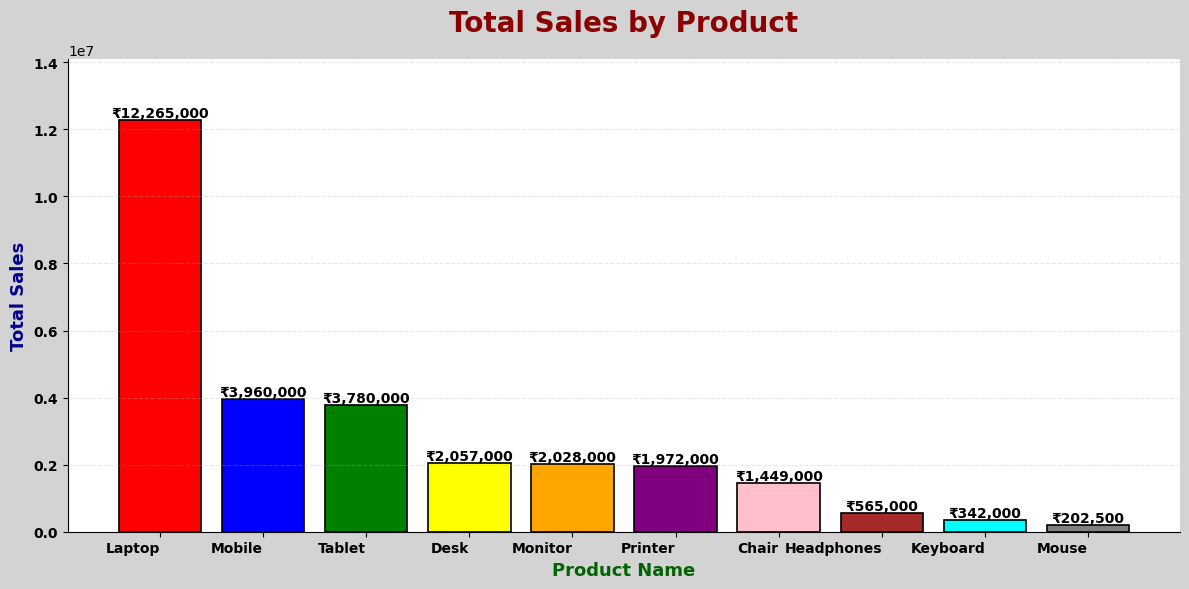

In [131]:
plt.figure(figsize=(12, 6), facecolor="lightgray")
bars = plt.bar(
    product_sales["Product"],
    product_sales["Sales"],
    color=["red", "blue", "green", "yellow", "orange",
           "purple", "pink", "brown", "cyan", "gray"],
    edgecolor="black",
    linewidth=1.2
)

# Chart Title
plt.title(
    "Total Sales by Product",
    fontsize=20,
    fontweight="bold",
    color="darkred",
    pad=20
)

# x-Axis Labels
plt.xlabel(
    "Product Name",
    fontsize=13,
    fontweight="bold",
    color="darkgreen"
)

# y-Axis Labels
plt.ylabel(
    "Total Sales",
    fontsize=13,
    fontweight="bold",
    color="darkblue"
)

# Product names
plt.xticks(
    rotation=0,
    ha="right",
    fontsize=10,
    fontweight="bold"
)

# Total Sales
plt.yticks(
    fontsize=10,
    fontweight="bold"
)

# Background
plt.gca().set_facecolor("white")

# Light grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Sales value bar ke upar
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
    
# Y-axis me thoda extra space
plt.ylim(
    0,
    product_sales["Sales"].max() * 1.15
)

# Layout adjust
plt.tight_layout()


# Border/spines ko clean kiya
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.show()

Q32. Create a Bar Chart showing category-wise Sales.

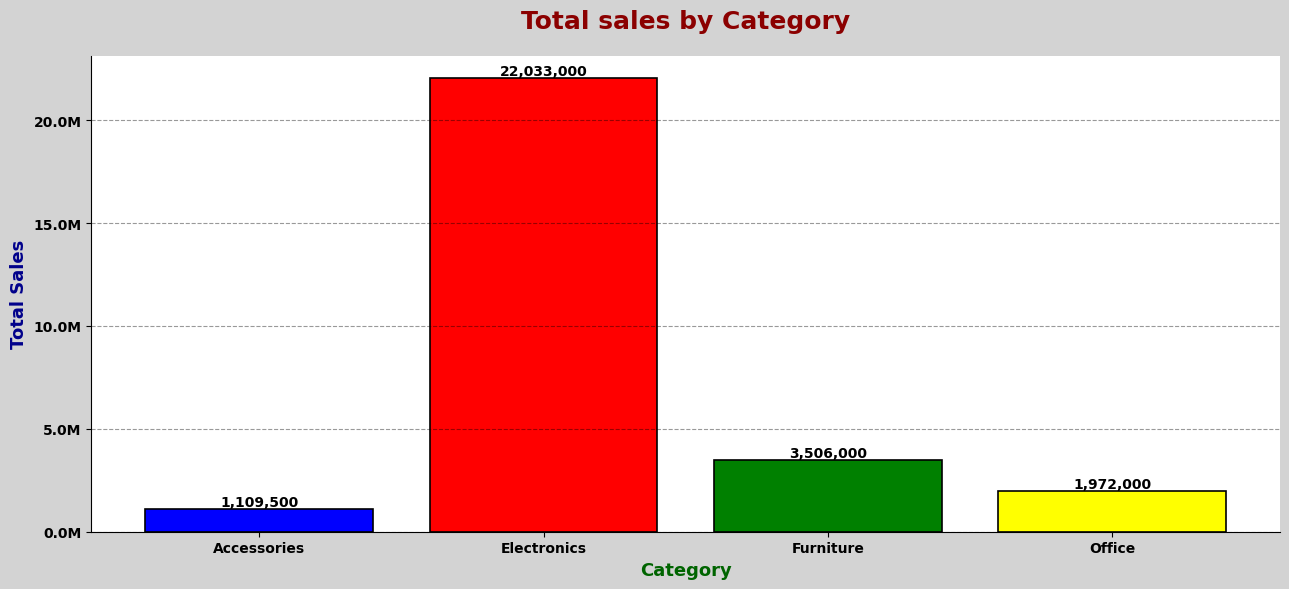

In [132]:
plt.figure(figsize=(13, 6), facecolor="lightgray")
bar = plt.bar(
    Total_Category.index, 
    Total_Category.values,
    color = ["blue", "red", "green", "yellow"],
    edgecolor="black",
    linewidth=1.2
)
plt.title("Total sales by Category",         
    fontsize=18, 
    fontweight="bold", 
    color="darkred",
    pad=20
)

plt.xlabel("Category", 
    fontsize=13,
    fontweight="bold",
    color= "darkgreen"
)
plt.ylabel("Total Sales",
    fontsize=13,
    fontweight="bold",
    color= "darkblue"
)

# Product names
plt.xticks(
    rotation=0,
    ha="center",
    fontsize=10,
    fontweight="bold"
)

# Total_sales
plt.yticks(
    fontsize=10,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
    color="black"
)
# Y-axis ko readable format mein
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

# Sales value bar ke upar
for b in bar:
    height = b.get_height()
    plt.text(
        b.get_x() + b.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Layout adjust
plt.tight_layout()

# Border/spines ko clean kiya
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.show()

Q33. Create a Bar Chart showing city-wise Sales.

Q34. Create a Bar Chart showing region-wise Sales.

Q35. Create a Bar Chart showing salesperson-wise Sales.

Q36. Create a Pie Chart showing the number of Orders by Payment Mode.

Q37. Create a Pie Chart showing the percentage of Sales by Category.

Q38. Create a Line Chart showing month-wise Sales.

Q39. Create a Line Chart showing the Sales trend according to OrderDate.

Q40. Create a Bar Chart showing product-wise Quantity.

Q41. Create a Scatter Plot showing the relationship between UnitPrice and Sales.

Q42. Create a Scatter Plot showing the relationship between Quantity and Sales.

Q43. Create a Bar Chart showing the Top 10 orders with the highest Sales.

Q44. Create a Bar Chart showing the number of Orders by Salesperson.

Q45. Create a Line Chart showing monthly Sales by Category.